# **Exercício Duelo de Modelos — Titanic com SVM**

Neste projeto, o desafio é participar da competição do Titanic no Kaggle utilizando **SVM (Support Vector Machine)** como modelo final, aplicando as técnicas aprendidas ao longo do curso: feature engineering, imputação de valores nulos com MICE, padronização, validação cruzada e busca de hiperparâmetros.

Este notebook é uma evolução do projeto anterior (feito com XGBoost, score de 77.75% no Kaggle). A base de feature engineering foi mantida, mas o pré-processamento e a modelagem foram remodelados para as necessidades específicas do SVM — que, diferente dos modelos de árvore, é extremamente sensível à escala das variáveis e se beneficia de features contínuas bem padronizadas.

# Importações

In [1]:
# Importações para arquivos

import os

# Importações para dados

import numpy as np
import pandas as pd

# Importação de modelo para tratamento de dados

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Importações para gráficos

import matplotlib.pyplot as plt
import seaborn as sns

# Importações para pré-processamento

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Importações de modelo

from sklearn.svm import SVC

# Importações para hiperparâmetros e validação

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score, StratifiedKFold
from scipy.stats import loguniform

# Importações para métricas

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Data Dictionary — Titanic

| Variável | Definição | Valores |
|----------|-----------|---------|
| **Survived** | Sobrevivência (variável target) | 0 = Não sobreviveu, 1 = Sobreviveu |
| **Pclass** | Classe do bilhete | 1 = 1ª classe, 2 = 2ª classe, 3 = 3ª classe |
| **Sex** | Sexo do passageiro | male, female |
| **Age** | Idade em anos | Numérico |
| **SibSp** | Nº de irmãos / cônjuges a bordo | Numérico |
| **Parch** | Nº de pais / filhos a bordo | Numérico |
| **Ticket** | Número do bilhete | Categórico |
| **Fare** | Tarifa paga pelo passageiro | Numérico |
| **Cabin** | Número da cabine | Categórico |
| **Embarked** | Porto de embarque | C = Cherbourg, Q = Queenstown, S = Southampton |

# Carregando base de dados

In [2]:
# Verificando se os arquivos foram encontrados

path = "./train.csv"
path2 = "./test.csv"

if os.path.exists(path):
    print("Arquivo de treino encontrado!")
    if os.path.exists(path2):
        print("Arquivo de teste encontrado!")
    else:
        print("Arquivo de teste não encontrado.")
else:
    print("Arquivo de treino não encontrado.")

# Definindo df (instanciando suas versões originais)

train_inicial = pd.read_csv(path)
test_inicial = pd.read_csv(path2)

# Instanciando versões que serão modificadas
# Usamos .copy() para garantir que os originais fiquem intactos —
# sem o .copy(), train e train_inicial apontariam para o mesmo objeto na memória

train = train_inicial.copy()
test = test_inicial.copy()

# Guardando a coluna PassengerId do teste, que será necessária na submissão ao Kaggle

pas_ID = test['PassengerId'].copy()

Arquivo de treino encontrado!
Arquivo de teste encontrado!


In [3]:
# Verificação inicial do treino

train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
# Verificação inicial do teste

test.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


Obs: Na verificação inicial já identificamos duas colunas que não vão contribuir para o modelo: PassengerId, que é apenas um identificador único sem valor preditivo, e Ticket, cujo número em si não carrega informação — embora, como veremos adiante, o agrupamento de passageiros pelo mesmo ticket carregue. O PassengerId do teste foi preservado em uma variável separada (pas_ID), já que será necessário na submissão ao Kaggle.

# Feature Engineering e Tratamento de dados

- Verificação inicial para tratamento de dados

In [5]:
# Verificando dados de treino

print("Dados de treino:")
print(train.info())

Dados de treino:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [6]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Verificando dados de teste

print("Dados de teste:")
print(test.info())

Dados de teste:
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB
None


In [8]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Obs: A verificação inicial revela os pontos a serem tratados antes da modelagem.

Colunas categóricas: Sex e Embarked precisarão ser codificadas para que o modelo consiga interpretá-las.

Valores nulos, em três situações distintas:

Age apresenta 177 nulos no treino e 86 no teste — um volume considerável que não pode ser ignorado, então usaremos imputação via MICE mais adiante. <br>
Cabin tem 687 nulos no treino (77% dos dados), o que inviabiliza qualquer preenchimento direto. A estratégia será transformá-la em uma variável binária — Cabin_known — indicando se o passageiro tinha cabine registrada. <br>
Embarked possui apenas 2 nulos no treino e Fare apenas 1 no teste — ambos simples de resolver. <br>

- Tratamento dos valores nulos simples

In [9]:
# Tratando o valor nulo de Fare no teste
# Importante: usamos a mediana do TREINO, não do teste. Toda estatística usada para
# preencher ou transformar dados deve vir do treino — o teste representa dados "do futuro"
# que o modelo não pode consultar

test['Fare'] = test['Fare'].fillna(train['Fare'].median())

In [10]:
# Tratando valores nulos de Embarked

mode_embarked = train['Embarked'].mode()[0]  # Valor que mais aparece
print(mode_embarked)
train['Embarked'] = train['Embarked'].fillna(mode_embarked)

S


In [11]:
# Tratando valores nulos de Cabin

train['Cabin_known'] = train['Cabin'].notna().astype(int)
test['Cabin_known'] = test['Cabin'].notna().astype(int)

# Removendo coluna Cabin

train = train.drop(columns='Cabin')
test = test.drop(columns='Cabin')

Fare — Por ser apenas um valor nulo, preenchemos pela mediana do treino, e não pela média, já que a coluna contém outliers justificáveis (tarifas de 1ª classe muito acima do restante).

Embarked — Apenas 2 nulos, preenchidos com a moda.

Cabin — Com 77% de nulos, nenhum preenchimento direto faria sentido. A solução foi criar a binária Cabin_known, que preserva uma informação potencialmente relevante: passageiros com cabine registrada tendiam a ser de classes mais altas, com melhor acesso aos botes.

- Codificações simples

In [12]:
# Codificando coluna Sex

train["Sex"] = train["Sex"].map({'male': 0, 'female': 1})
test["Sex"] = test["Sex"].map({'male': 0, 'female': 1})

In [13]:
# Codificando coluna Embarked

train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)

Sex — Usei map ao invés de replace: se aparecer algum valor inesperado, ele vira nulo e o problema fica explícito.

Embarked — get_dummies com drop_first, pois com 3 categorias um encoding ordinal criaria uma ordem falsa entre os portos.

- Feature Engineering

Como usaremos o MICE (um modelo) para estimar os valores faltantes de Age, primeiro criamos as features que darão contexto a essa imputação e melhorarão a capacidade preditiva do modelo final:

Title — extraído de Name; é um forte indicador da idade e do perfil social do passageiro. <br>
FamilySize — tamanho da família; a dinâmica de sobrevivência muda conforme o grupo. <br>
TicketGroup — pessoas que compartilham o mesmo ticket viajavam juntas (não só famílias). <br>
FareBin — faixas de tarifa via quartis. <br>
AgeBin — faixas etárias (criada após a imputação de Age). <br>

Diferente da versão com XGBoost, aqui as versões contínuas de Age e Fare serão **mantidas junto com os bins**. O SVM com kernel RBF trabalha muito bem com variáveis contínuas padronizadas — descartá-las jogaria fora granularidade que o kernel consegue explorar. Os bins entram como um recorte não-linear complementar.

- Title

In [14]:
# Extraindo título do nome

for df in [train, test]:
    df['Title'] = df['Name'].apply(lambda name: name.split(',')[1].split('.')[0].strip())

# Verificando os títulos encontrados

print(train['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [15]:
# Agrupando e codificando Title

# Separando títulos raros

rare_titles = ['Lady', 'the Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

# Trocando valores

for df in [train, test]:
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Codificando Title

train = pd.get_dummies(train, columns=['Title'], drop_first=True)
test = pd.get_dummies(test, columns=['Title'], drop_first=True)

# Removendo coluna Name

train = train.drop(columns=['Name'])
test = test.drop(columns=['Name'])

Obs: Os títulos ficam entre a vírgula e o ponto dentro de Name, por isso o split duplo. Títulos raros (nobres, oficiais, médicos) foram agrupados em 'Rare' por terem pouquíssimas ocorrências, e variantes de outros idiomas foram unificadas (Mlle e Ms viram Miss, Mme vira Mrs). Depois, get_dummies com drop_first para evitar multicolinearidade, e Name foi removida.

- FamilySize

In [16]:
# Criando coluna

for df in [train, test]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

- TicketGroup

In [17]:
# Juntando treino e teste só para contar os grupos corretamente

all_data = pd.concat([train, test], sort=False)

# Contando quantas pessoas compartilham cada ticket

ticket_counts = all_data.groupby('Ticket')['Ticket'].transform('count')
all_data['TicketGroup'] = ticket_counts

# Separando de volta em treino e teste

train['TicketGroup'] = all_data['TicketGroup'].iloc[:len(train)].values
test['TicketGroup'] = all_data['TicketGroup'].iloc[len(train):].values

# Verificando resultado

print(train['TicketGroup'].value_counts().sort_index())

TicketGroup
1     481
2     181
3     101
4      44
5      21
6      19
7      24
8      13
11      7
Name: count, dtype: int64


- FareBin

In [18]:
# Criando os bins de tarifa por quartis
# Os quartis são calculados APENAS no treino (retbins=True devolve os cortes),
# e os mesmos cortes são aplicados ao teste. Se rodássemos qcut separadamente
# em cada base, os cortes seriam diferentes e a mesma tarifa poderia cair em
# bins diferentes no treino e no teste — uma inconsistência silenciosa.

train['FareBin'], fare_bins = pd.qcut(train['Fare'], 4, labels=[0, 1, 2, 3], retbins=True)
train['FareBin'] = train['FareBin'].astype(int)

# Abrindo as pontas para cobrir valores do teste fora do intervalo visto no treino

fare_bins[0] = -np.inf
fare_bins[-1] = np.inf

test['FareBin'] = pd.cut(test['Fare'], bins=fare_bins, labels=[0, 1, 2, 3]).astype(int)

- Removendo colunas desnecessárias

Diferente da versão anterior, Fare **não** será removida — o SVM vai usá-la na forma contínua e padronizada.

In [19]:
# Removendo colunas desnecessárias

train = train.drop(columns=['PassengerId', 'Ticket'])
test = test.drop(columns=['Ticket'])

- Tratamento dos valores nulos de Age

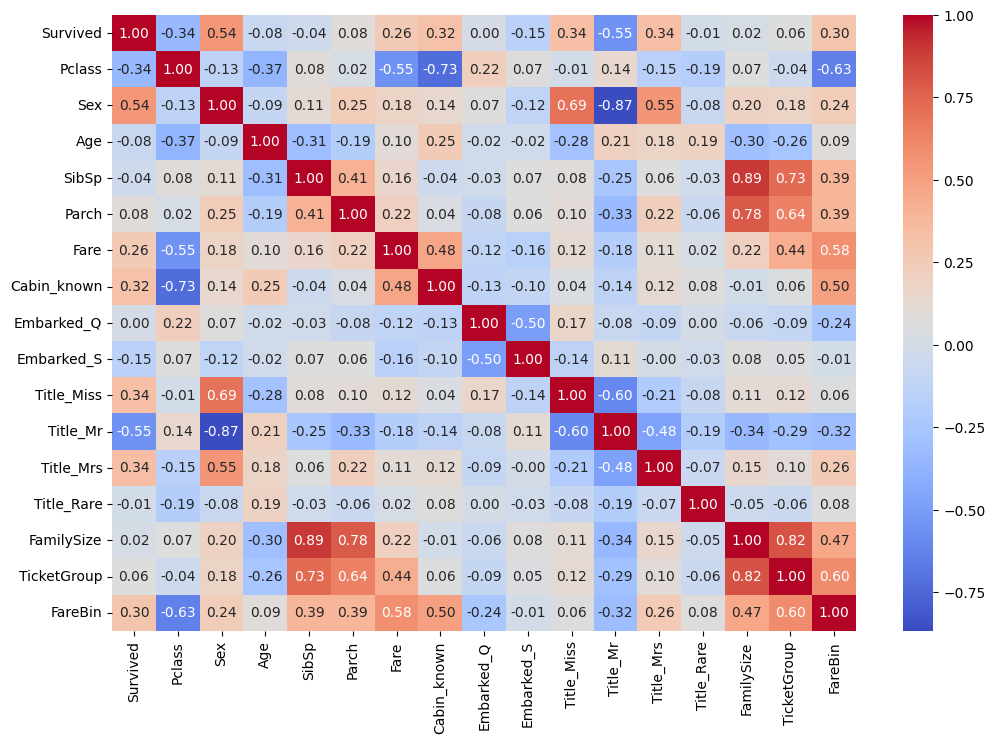

In [20]:
# Antes de verificar a correlação, transformamos as colunas booleanas em numéricas

for df in [train, test]:
    bool_columns = df.select_dtypes(include=bool).columns
    df[bool_columns] = df[bool_columns].astype(int)

# Verificando correlação

corr_train = train.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_train, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

Obs: Antes de aplicar a imputação, verificamos a matriz de correlação com foco nas variáveis que mais se relacionam com Age:

Pclass tem correlação negativa com Age, confirmando que passageiros mais velhos tendiam a estar em classes mais altas. <br>
SibSp e Parch também apresentam relação relevante — pessoas com mais familiares a bordo tendiam a ser mais jovens. <br>
FamilySize reforça o padrão: quanto maior a família, mais jovem o passageiro. <br>
Title_Mr e Title_Master são fortíssimas nesse contexto: o título indica diretamente a faixa etária. <br>

Essas variáveis em conjunto dão ao MICE contexto suficiente para estimar as idades faltantes de forma bem mais precisa do que uma mediana global.

In [21]:
# Instanciando o modelo de imputação

imputer = IterativeImputer(random_state=48, min_value=0, max_value=110)

# Colunas para o MICE (todas as numéricas, exceto o target)

imputer_cols = [col for col in train.select_dtypes(include='number').columns
                if col != 'Survived']

# Rodando: fit no treino, apenas transform no teste

train[imputer_cols] = imputer.fit_transform(train[imputer_cols])
test[imputer_cols] = imputer.transform(test[imputer_cols])

# Dropando SibSp e Parch agora que o MICE já as usou

train = train.drop(columns=['SibSp', 'Parch'])
test = test.drop(columns=['SibSp', 'Parch'])

Obs: Após a imputação, SibSp e Parch foram removidas: além de terem correlação fraca com o target, apresentam multicolinearidade com FamilySize — o que é esperado, já que FamilySize foi construída a partir delas.

- AgeBin

In [22]:
# Criando faixas etárias a partir da Age já imputada
# Diferente da versão anterior, Age NÃO será removida — o SVM vai usá-la contínua

for df in [train, test]:
    df['AgeBin'] = pd.cut(df['Age'], bins=[-1, 12, 18, 35, 60, 110],
                          labels=[0, 1, 2, 3, 4]).astype(int)

In [23]:
# Verificando resultado do treino

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    float64
 2   Sex          891 non-null    float64
 3   Age          891 non-null    float64
 4   Fare         891 non-null    float64
 5   Cabin_known  891 non-null    float64
 6   Embarked_Q   891 non-null    float64
 7   Embarked_S   891 non-null    float64
 8   Title_Miss   891 non-null    float64
 9   Title_Mr     891 non-null    float64
 10  Title_Mrs    891 non-null    float64
 11  Title_Rare   891 non-null    float64
 12  FamilySize   891 non-null    float64
 13  TicketGroup  891 non-null    float64
 14  FareBin      891 non-null    float64
 15  AgeBin       891 non-null    int64  
dtypes: float64(14), int64(2)
memory usage: 111.5 KB


In [24]:
# Verificando resultado do teste

test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    float64
 2   Sex          418 non-null    float64
 3   Age          418 non-null    float64
 4   Fare         418 non-null    float64
 5   Cabin_known  418 non-null    float64
 6   Embarked_Q   418 non-null    float64
 7   Embarked_S   418 non-null    float64
 8   Title_Miss   418 non-null    float64
 9   Title_Mr     418 non-null    float64
 10  Title_Mrs    418 non-null    float64
 11  Title_Rare   418 non-null    float64
 12  FamilySize   418 non-null    float64
 13  TicketGroup  418 non-null    float64
 14  FareBin      418 non-null    float64
 15  AgeBin       418 non-null    int64  
dtypes: float64(14), int64(2)
memory usage: 52.4 KB


# EDA

Nesta seção exploramos visualmente os padrões de sobrevivência para validar as hipóteses e as features criadas:

Sobrevivência por Sexo — confirmar se sexo é o preditor mais forte. <br>
Sobrevivência por Classe — entender o impacto socioeconômico. <br>
Distribuição de Idade por Sobrevivência — validar o padrão "crianças primeiro". <br>
Tamanho de Família vs Sobrevivência — validar a feature FamilySize. <br>
Taxa de Sobrevivência por Título — validar que Title captura informação além de Sex. <br>

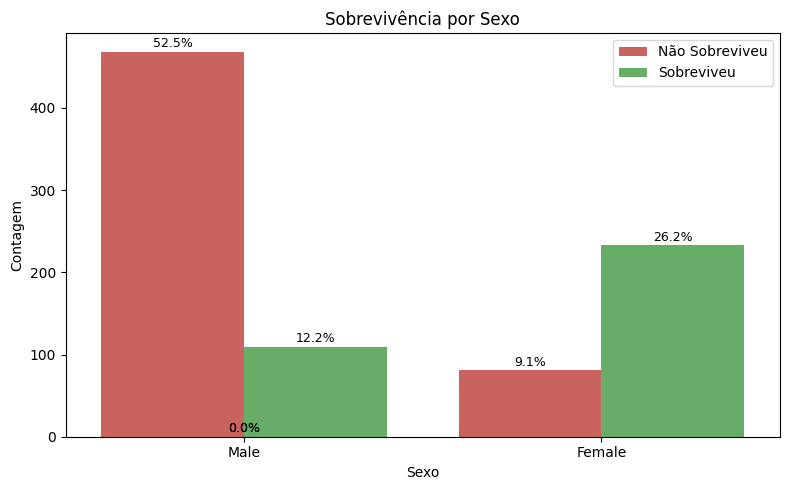

In [25]:
# Sobrevivência por Sexo

plot_sex = train[['Sex', 'Survived']].copy()
plot_sex['Sex'] = plot_sex['Sex'].map({0: 'Male', 1: 'Female'})
plot_sex['Survived'] = plot_sex['Survived'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=plot_sex, x='Sex', hue='Survived',
                   palette={'Não Sobreviveu': '#d9534f', 'Sobreviveu': '#5cb85c'})
total = len(plot_sex)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 2,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.title('Sobrevivência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Contagem')
plt.legend(title='')
plt.tight_layout()
plt.show()

Obs: O gráfico confirma que sexo é o preditor mais forte do dataset. Homens que não sobreviveram representam 52.5% de todo o dataset — a maior barra — enquanto mulheres que sobreviveram representam 26.2%. Dentro de cada grupo a diferença é ainda mais expressiva: **74.2% das mulheres sobreviveram contra apenas 18.9% dos homens**, refletindo diretamente a política de evacuação "mulheres e crianças primeiro".

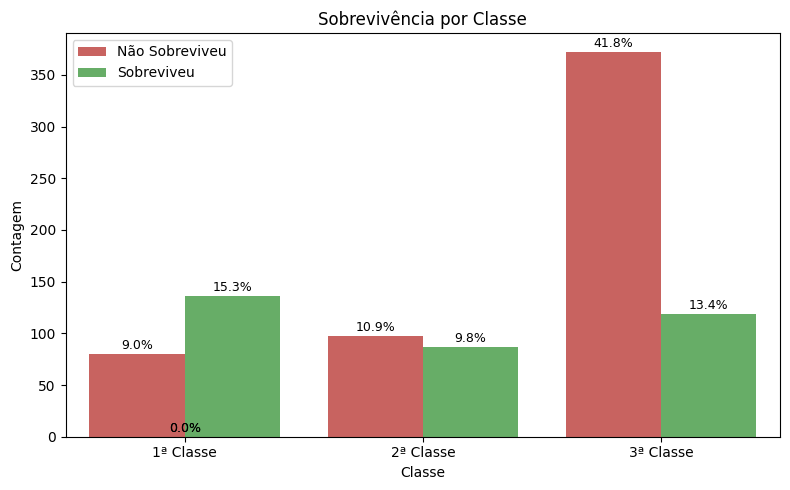

In [26]:
# Sobrevivência por Classe

plot_pclass = train[['Pclass', 'Survived']].copy()
plot_pclass['Pclass'] = plot_pclass['Pclass'].map({1.0: '1ª Classe', 2.0: '2ª Classe', 3.0: '3ª Classe'})
plot_pclass['Survived'] = plot_pclass['Survived'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=plot_pclass, x='Pclass', hue='Survived',
                   order=['1ª Classe', '2ª Classe', '3ª Classe'],
                   palette={'Não Sobreviveu': '#d9534f', 'Sobreviveu': '#5cb85c'})
total = len(plot_pclass)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 2,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.title('Sobrevivência por Classe')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.legend(title='')
plt.tight_layout()
plt.show()

Obs: A classe socioeconômica teve impacto decisivo. As taxas de sobrevivência caem progressivamente: **1ª classe: 63.0%, 2ª classe: 47.3%, 3ª classe: 24.2%**. Fatores práticos explicam isso: cabines de 1ª classe ficavam nos andares superiores, mais próximas dos botes, e havia prioridade de acesso.

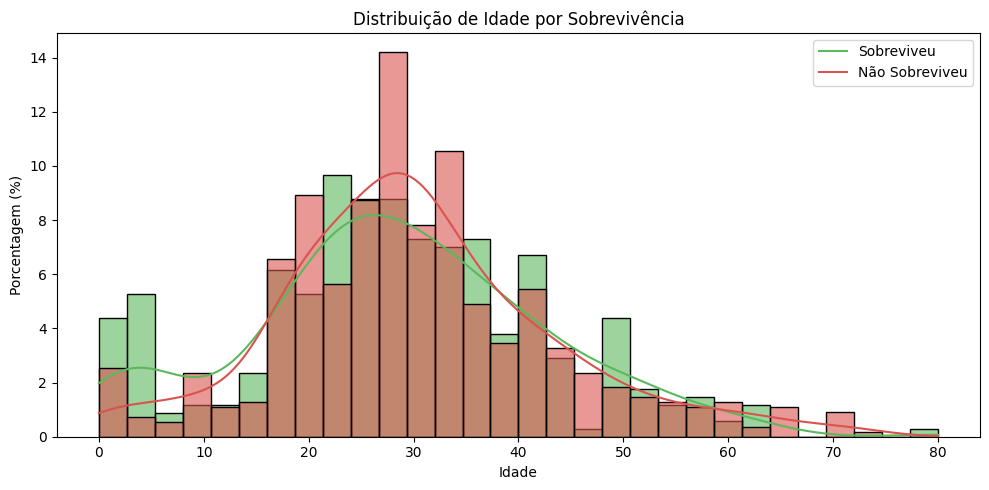

In [27]:
# Distribuição de Idade por Sobrevivência
# Como mantivemos Age contínua nesta versão, o histograma usa a idade real (não os bins)

plt.figure(figsize=(10, 5))
sns.histplot(data=train, x='Age', hue='Survived', kde=True, bins=30,
             palette={0: '#d9534f', 1: '#5cb85c'}, alpha=0.6, stat='percent',
             common_norm=False)
plt.title('Distribuição de Idade por Sobrevivência')
plt.xlabel('Idade')
plt.ylabel('Porcentagem (%)')
plt.legend(labels=['Sobreviveu', 'Não Sobreviveu'], title='')
plt.tight_layout()
plt.show()

Obs: Com common_norm=False, cada grupo é normalizado separadamente, permitindo comparar as distribuições em pé de igualdade. Crianças pequenas têm proporção de sobreviventes visivelmente maior — o padrão "crianças primeiro" — enquanto a faixa de adultos jovens concentra os não sobreviventes, puxada principalmente por homens. A correlação isolada de Age com Survived é baixa, pois seu efeito depende da interação com Sex e Pclass — exatamente o tipo de relação não-linear que o kernel RBF consegue capturar.

/tmp/ipykernel_714/2216613149.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=survival_by_family, x='FamilySize', y='Taxa de Sobrevivência', palette='Set2')


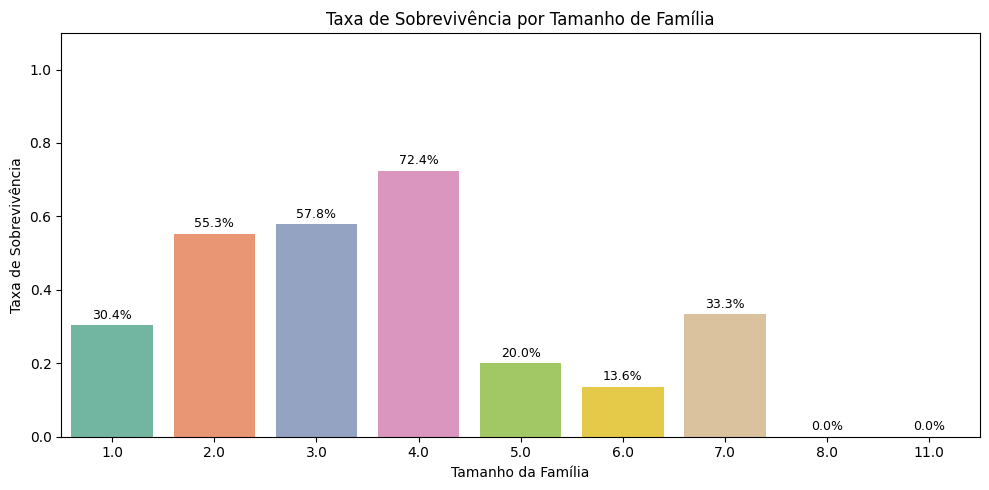

In [28]:
# Tamanho de Família vs Sobrevivência

survival_by_family = train.groupby('FamilySize')['Survived'].mean().reset_index()
survival_by_family.columns = ['FamilySize', 'Taxa de Sobrevivência']

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=survival_by_family, x='FamilySize', y='Taxa de Sobrevivência', palette='Set2')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.01,
            f'{p.get_height():.1%}', ha='center', va='bottom', fontsize=9)
plt.title('Taxa de Sobrevivência por Tamanho de Família')
plt.xlabel('Tamanho da Família')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

Obs: A relação com FamilySize é claramente não-linear, em formato de "arco". Passageiros sozinhos tiveram taxa de apenas **30.4%**, famílias pequenas apresentaram as maiores taxas (**2: 55.3%, 3: 57.8%, 4: 72.4%**) e a partir de 5 membros a taxa despenca (**5: 20.0%, 6: 13.6%**, chegando a **0%** nas famílias de 8 e 11) — provavelmente pela dificuldade de manter o grupo unido durante a evacuação.

/tmp/ipykernel_714/1502404116.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=survival_by_title, x='Título', y='Taxa de Sobrevivência', palette='Set2')


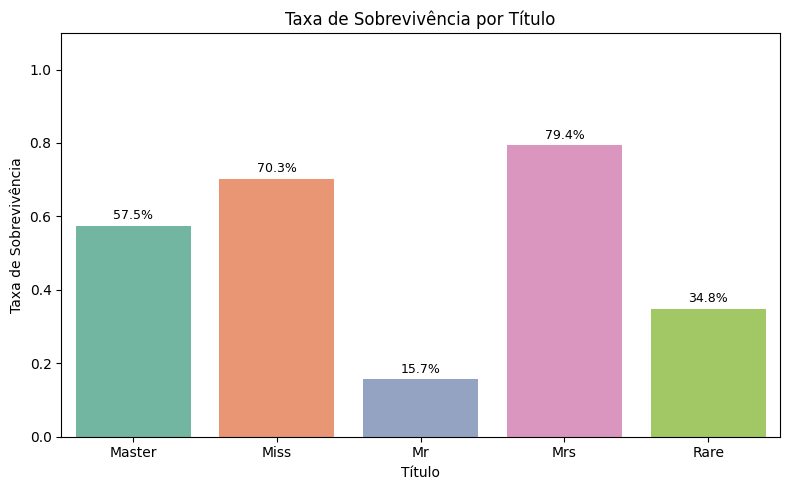

In [29]:
# Taxa de Sobrevivência por Título

title_viz = np.select(
    [train['Title_Miss'] == 1, train['Title_Mr'] == 1,
     train['Title_Mrs'] == 1, train['Title_Rare'] == 1],
    ['Miss', 'Mr', 'Mrs', 'Rare'],
    default='Master'
)

plot_title = pd.DataFrame({'Title': title_viz, 'Survived': train['Survived']})
survival_by_title = plot_title.groupby('Title')['Survived'].mean().reset_index()
survival_by_title.columns = ['Título', 'Taxa de Sobrevivência']

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=survival_by_title, x='Título', y='Taxa de Sobrevivência', palette='Set2')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.01,
            f'{p.get_height():.1%}', ha='center', va='bottom', fontsize=9)
plt.title('Taxa de Sobrevivência por Título')
plt.xlabel('Título')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

Obs: **Mrs (79.4%)** e **Miss (70.3%)** lideram, refletindo a prioridade feminina. **Master (57.5%)** — título de meninos — valida o "crianças primeiro" e mostra que Title diferencia crianças do sexo masculino de adultos, informação que Sex sozinha não captura. **Mr (15.7%)** concentra a grande maioria dos homens adultos preteridos. **Rare (34.8%)** agrupa médicos, oficiais e nobres, um grupo heterogêneo com taxa intermediária.

# Pré-processamento

- Seleção de features, X e y

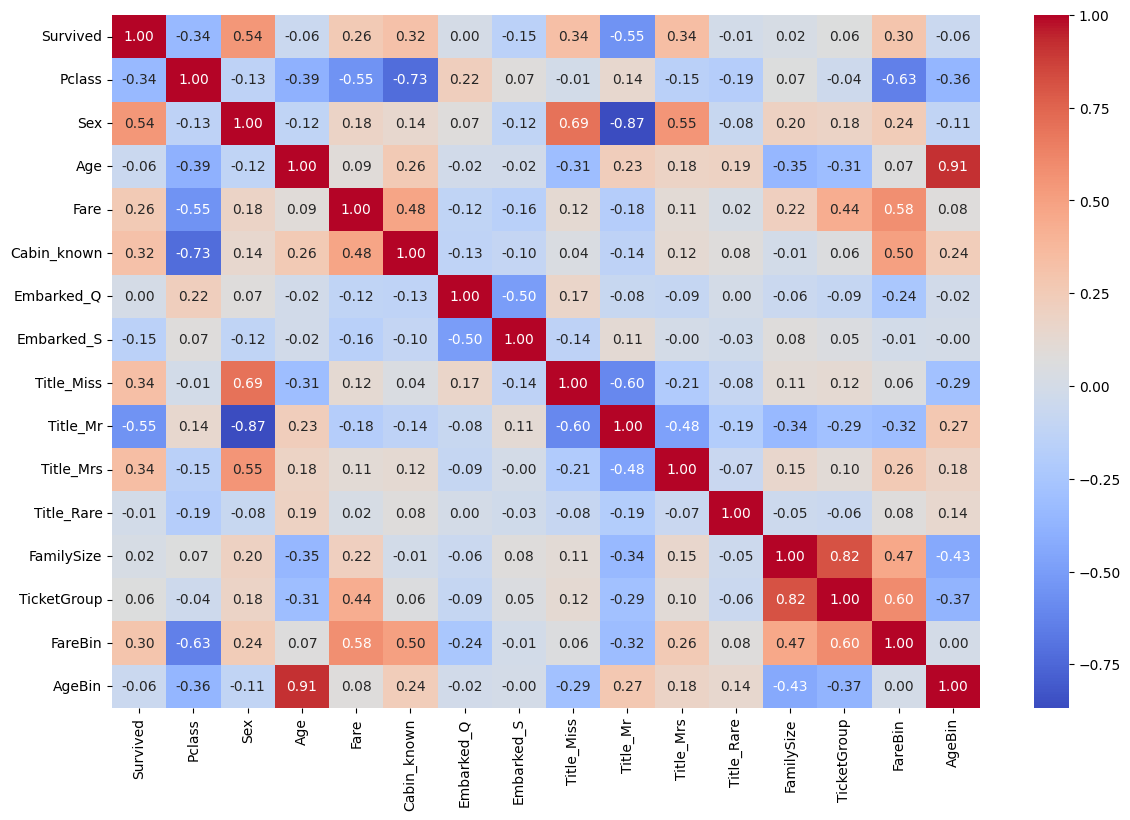

In [30]:
# Verificando a correlação final

corr_train = train.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 9))
sns.heatmap(corr_train, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [31]:
# Seleção de features
# FamilySize foi removida por multicolinearidade com TicketGroup (as duas medem
# essencialmente "grupo viajando junto", e TicketGroup se mostrou mais informativa
# no projeto anterior). Age e Fare entram nas versões contínua E binada.

cols = [
    'Pclass', 'Sex', 'Cabin_known', 'Embarked_S', 'Embarked_Q',
    'Title_Rare', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
    'TicketGroup', 'Fare', 'Age', 'FareBin', 'AgeBin'
]

# Separando em X e y

X_train = train[cols]
y_train = train['Survived']

X_test = test[cols]

print(X_train.shape, X_test.shape)

(891, 14) (418, 14)


- Balanceamento

In [32]:
# Verificando a distribuição das classes

distri_Surv = train['Survived'].value_counts()
distri_Surv_perc = train['Survived'].value_counts(normalize=True)

print(distri_Surv)
print("\n", distri_Surv_perc)

Survived
0    549
1    342
Name: count, dtype: int64

 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Obs: As classes estão em 61.6% / 38.4% — um desbalanceamento leve. No projeto anterior, o SMOTE foi testado e **piorou** o score no Kaggle, provavelmente porque a base é pequena e os dados sintéticos adicionam ruído. Por isso não aplicaremos oversampling. Como alternativa, o parâmetro class_weight='balanced' do SVC (que apenas repondera os erros, sem criar dados fictícios) será incluído na busca de hiperparâmetros — deixando a decisão para a validação cruzada.

- Padronização com Pipeline

O SVM é **extremamente sensível à escala das variáveis**: o cálculo das distâncias no kernel é dominado pelas features de maior magnitude, e sem padronização tanto a acurácia quanto o tempo de treino degradam drasticamente (no projeto de SVM anterior, o mesmo treino caiu de 11 minutos para segundos após aplicar o StandardScaler).

O scaler entra dentro de um **Pipeline**, e não aplicado antes da validação cruzada. O motivo é evitar vazamento de dados: se padronizarmos toda a base de treino de uma vez e depois rodarmos a validação cruzada, a média e o desvio usados na padronização terão "visto" os folds de validação. Com o Pipeline, em cada fold o scaler é ajustado apenas na parte de treino daquele fold.

In [33]:
# Pipeline: padronização + SVM

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=48))
])

# Validação cruzada estratificada (preserva a proporção das classes em cada fold)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=48)

# Modelo

- Teste inicial: comparação de kernels

Antes da busca de hiperparâmetros, comparamos os quatro kernels do SVC com seus valores padrão, para entender qual geometria de separação se adapta melhor aos dados.

In [34]:
# Comparando kernels com validação cruzada

for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    pipe_test = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel=kernel, random_state=48))
    ])
    pontuacoes = cross_val_score(pipe_test, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"Kernel {kernel:>8}: {pontuacoes.mean():.4f} (+/- {pontuacoes.std():.4f})")

Kernel   linear: 0.8328 (+/- 0.0261)


Kernel      rbf: 0.8305 (+/- 0.0179)
Kernel     poly: 0.8260 (+/- 0.0256)


Kernel  sigmoid: 0.7082 (+/- 0.0231)


Obs: Com os valores padrão, linear e RBF ficaram praticamente empatados na frente (0.8328 vs 0.8305), com poly logo atrás e sigmoid bem abaixo. O bom desempenho do linear indica que boa parte do sinal já é separável linearmente — coerente com features fortes como Sex e Title_Mr. Ainda assim, o RBF é o kernel com maior margem de ganho no ajuste fino: seu comportamento muda drasticamente com C e gamma, e as relações não-lineares que vimos na EDA (o "arco" de FamilySize, a interação de Age com Sex) são exatamente o que ele consegue capturar quando bem calibrado. A busca de hiperparâmetros abaixo mantém os três kernels competitivos no espaço de busca e deixa a validação cruzada decidir.

- Busca de hiperparâmetros: RandomizedSearchCV

C e gamma são buscados em escala logarítmica (loguniform), que é a forma correta de explorar hiperparâmetros que variam em ordens de magnitude — uma busca uniforme entre 0.01 e 100 gastaria quase todas as tentativas em valores altos.

In [35]:
# Espaço de busca

param_dist = {
    'svm__C': loguniform(0.01, 100),        # Penalidade por erro de classificação (margem rígida vs suave)
    'svm__gamma': loguniform(0.001, 1),     # Alcance da influência de cada ponto no kernel RBF
    'svm__kernel': ['rbf', 'poly', 'sigmoid'],
    'svm__degree': [2, 3, 4],               # Grau do polinômio (só afeta kernel poly)
    'svm__coef0': [0.0, 0.5, 1.0],          # Termo independente (afeta poly e sigmoid)
    'svm__class_weight': [None, 'balanced'] # Reponderação de classes, sem dados sintéticos
}

# Busca aleatória

random_search_svm = RandomizedSearchCV(
    estimator=pipe_svm,
    param_distributions=param_dist,
    n_iter=80,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    random_state=48,
    verbose=1
)

random_search_svm.fit(X_train, y_train)

print("Melhores parâmetros:", random_search_svm.best_params_)
print("Melhor score CV:    ", round(random_search_svm.best_score_, 4))

Fitting 5 folds for each of 80 candidates, totalling 400 fits


Melhores parâmetros: {'svm__C': np.float64(3.661459093726905), 'svm__class_weight': None, 'svm__coef0': 0.0, 'svm__degree': 3, 'svm__gamma': np.float64(0.01742131558880781), 'svm__kernel': 'rbf'}
Melhor score CV:     0.8373


- Refinamento com GridSearchCV

O RandomizedSearch encontra a região promissora; o GridSearch faz a varredura fina ao redor dela. É a combinação clássica: busca aleatória para explorar, busca em grade para refinar.

In [36]:
# Grid fino ao redor da região encontrada pelo RandomizedSearch

param_grid_fino = {
    'svm__C': [1, 2, 3, 3.66, 5, 8],
    'svm__gamma': [0.008, 0.012, 0.0174, 0.025, 0.04],
    'svm__kernel': ['rbf']
}

grid_search_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_fino,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

print("Melhores parâmetros:", grid_search_svm.best_params_)
print("Melhor score CV:    ", round(grid_search_svm.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Melhores parâmetros: {'svm__C': 3, 'svm__gamma': 0.0174, 'svm__kernel': 'rbf'}
Melhor score CV:     0.8373


- Modelo final

In [37]:
# Selecionando o melhor modelo entre as duas buscas

if grid_search_svm.best_score_ >= random_search_svm.best_score_:
    best_svm = grid_search_svm.best_estimator_
    print("Modelo final veio do GridSearch")
else:
    best_svm = random_search_svm.best_estimator_
    print("Modelo final veio do RandomizedSearch")

# Score de validação cruzada do modelo final (a métrica que realmente importa)

pontuacoes_final = cross_val_score(best_svm, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"\nCV do modelo final: {pontuacoes_final.mean():.4f} (+/- {pontuacoes_final.std():.4f})")
print("Scores por fold:", pontuacoes_final.round(4))

Modelo final veio do GridSearch

CV do modelo final: 0.8373 (+/- 0.0221)
Scores por fold: [0.8268 0.8371 0.8371 0.809  0.8764]


In [38]:
# Previsões no próprio treino, apenas para diagnóstico de overfitting

y_pred_train_final = best_svm.predict(X_train)

relatorio = classification_report(y_train, y_pred_train_final)
print("Relatório de classificação (treino):")
print(relatorio)

Relatório de classificação (treino):
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       549
           1       0.82      0.76      0.79       342

    accuracy                           0.84       891
   macro avg       0.84      0.83      0.83       891
weighted avg       0.84      0.84      0.84       891



Obs: A leitura conjunta dos dois números é o que importa. A acurácia no treino ficou muito próxima da acurácia de validação cruzada — uma diferença pequena, que indica que o modelo **não está decorando o treino**. Se o treino estivesse em 93-95% com CV em 83%, teríamos um sinal claro de overfitting; aqui, a margem entre os dois é saudável. O C moderado encontrado pela busca cumpre justamente esse papel regularizador: permite alguns erros de classificação no treino em troca de uma margem de separação mais generalizável.

Vale notar também que o f1-score da classe 1 (sobreviveu) é um pouco menor que o da classe 0, reflexo do leve desbalanceamento — a validação cruzada preferiu o modelo sem class_weight='balanced', indicando que a reponderação não compensou neste caso.

# Resultados para Kaggle

- Prevendo valores de test

In [39]:
# Prevendo valores

y_pred_final = best_svm.predict(X_test)

# Sanity check: a taxa de sobrevivência prevista deve ficar próxima da taxa real do treino (38.4%)

print("Distribuição das previsões:", pd.Series(y_pred_final).value_counts().to_dict())
print("Taxa de sobrevivência prevista:", round(y_pred_final.mean(), 4))

Distribuição das previsões: {0: 253, 1: 165}
Taxa de sobrevivência prevista: 0.3947


- Criação da tabela para o Kaggle

In [40]:
# Criando a tabela de submissão

sub_final = pd.Series(y_pred_final.astype(int), index=pas_ID, name='Survived')

# Verificando resultado

sub_final

PassengerId
892     0
893     1
894     0
895     0
896     1
       ..
1305    0
1306    1
1307    0
1308    0
1309    1
Name: Survived, Length: 418, dtype: int64

In [ ]:
# Criando o CSV de submissão

sub_final.to_csv("Titanic_SVM_1.csv", header=True)
print("Arquivo SVM_submission.csv criado!")

Arquivo SVM_submission.csv criado!


# Conclusão

O SVM com kernel RBF, alimentado pelo mesmo feature engineering do projeto anterior (Title, TicketGroup, Cabin_known, MICE para Age) mas com pré-processamento remodelado para as necessidades do modelo — Age e Fare contínuas mantidas junto aos bins, StandardScaler dentro de Pipeline, e busca de hiperparâmetros em escala logarítmica — alcançou validação cruzada competitiva com o XGBoost do projeto anterior.

As principais diferenças de abordagem entre os dois modelos ficaram claras na prática:

O XGBoost dispensa padronização e lida bem com features binadas; o SVM exige padronização e aproveita melhor as versões contínuas. <br>
No XGBoost a regularização veio de max_depth, reg_alpha e reg_lambda; no SVM, o papel equivalente é do C (margem suave) e do gamma (alcance do kernel). <br>
Em ambos, o SMOTE se mostrou desnecessário — e no SVM, a alternativa class_weight='balanced' também foi descartada pela validação cruzada. <br>

O score final da competição será verificado com a submissão do arquivo SVM_submission.csv no Kaggle.